# College Basketball Playstyle Clustering
A Data Science Case Study in Python

## 1. Project Overview
This project analyzes college basketball teams (2013-2024) by grouping them into playstyle clusters using advanced statistics from Torvik.
The goal is to identify which playstyles are most successful in the NCAA Tournament and apply those insights to evaluate current teams.


## 2. Data Loading and Preparation

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("cbb.csv")


In [3]:
features = [
   "ADJ_T",
    "EFG_O","EFG_D",
    "TOR","TORD",
    "ORB","DRB",
    "FTR","FTRD",
    "2P_O","2P_D",
    "3P_O","3P_D"
]

In [4]:
X = df[features].dropna()

df_model = df.loc[X.index].copy()

## 3. Clustering Playstyles

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_model["cluster"] = kmeans.fit_predict(X_scaled)

## 5. Playstyle Visualization (PCA Map)

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pcs = pca.fit_transform(X_scaled)

df_model["PC1"] = pcs[:,0]
df_model["PC2"] = pcs[:,1]

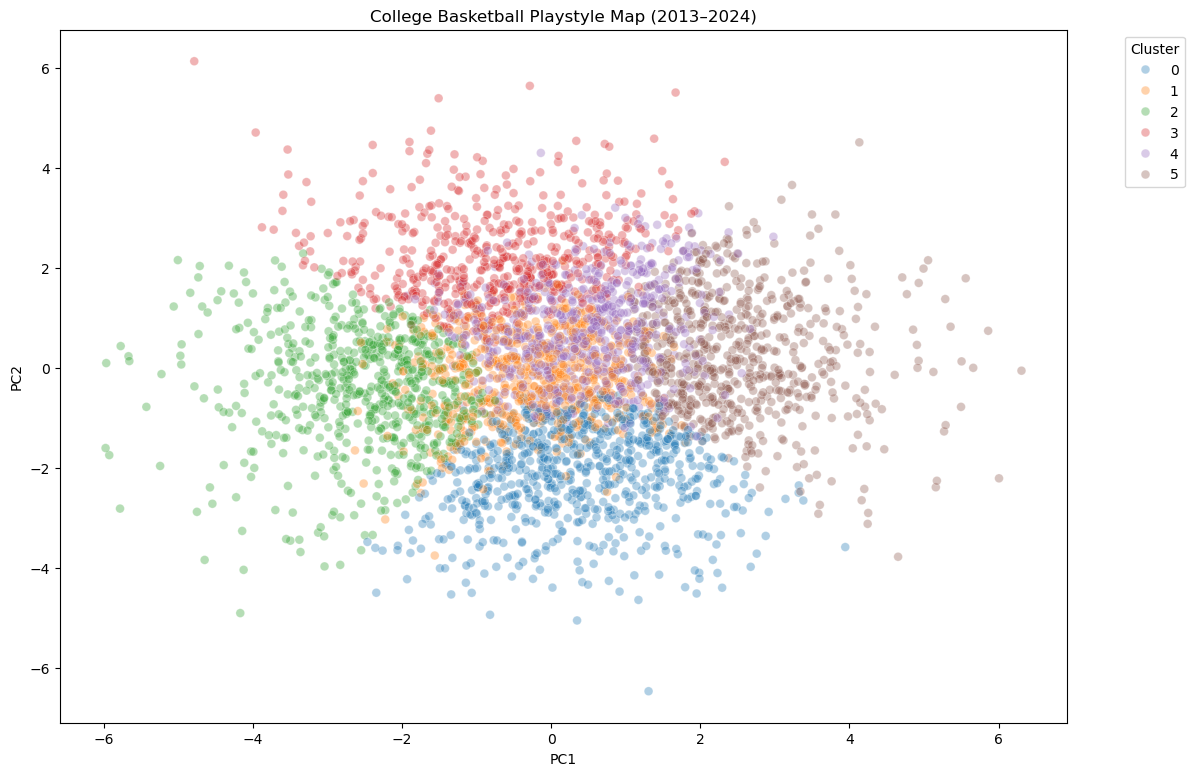

In [7]:
plt.figure(figsize=(13, 9))

sns.scatterplot(
    data=df_model,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.35,
    s=40,
    legend="full"
)

plt.title("College Basketball Playstyle Map (2013–2024)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

This chart shows how teams group into different playstyles based on their statistical profiles.

## 6. Understanding Cluster Playstyles

In [8]:
cluster_profile = df_model.groupby("cluster")[[
    "ADJOE","ADJDE","BARTHAG",
    "EFG_O","EFG_D",
    "TOR","TORD",
    "ORB","DRB",
    "FTR","FTRD",
    "2P_O","2P_D",
    "3P_O","3P_D",
    "ADJ_T","WAB"
]].mean().round(3)

cluster_profile

,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,ORB,DRB,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB
cluster,,,,,,,,,,,,,,,,,
0,106.633,96.298,0.724,50.093,46.454,18.618,18.969,32.503,29.089,36.321,33.935,49.473,45.503,34.205,32.178,66.244,-1.661
1,104.969,103.680,0.525,50.630,50.285,18.607,19.345,30.196,30.353,38.514,38.589,49.703,49.434,34.883,34.564,69.106,-6.741
2,95.521,105.275,0.279,45.909,50.402,20.466,19.681,30.836,31.773,36.075,40.276,45.318,49.503,31.366,34.738,66.744,-13.131
3,99.655,110.910,0.251,49.241,54.174,18.828,18.160,26.858,30.971,32.227,34.657,48.148,53.432,34.099,36.995,69.321,-14.153
4,101.330,104.399,0.423,49.416,50.817,17.936,17.364,26.874,27.808,30.341,31.010,48.918,50.498,33.488,34.243,66.888,-9.689
5,110.847,101.379,0.696,54.097,49.608,16.945,17.309,27.706,27.178,32.315,29.576,53.494,48.957,36.723,33.836,68.326,-2.182


## 7. Tournament Success by Playstyle

In [9]:
tournament_df = df_model[df_model["POSTSEASON"] != "Missed"]

In [10]:
important_stats = [
    "ADJ_T",
    "EFG_O","EFG_D",
    "TOR","TORD",
    "ORB",
    "3P_O"
]

cluster_profile_tourney = tournament_df.groupby("cluster")[important_stats].mean()

cluster_profile_tourney

,ADJ_T,EFG_O,EFG_D,TOR,TORD,ORB,3P_O
cluster,,,,,,,
0,66.243899,50.093268,46.453717,18.618373,18.969004,32.502805,34.205470
1,69.105680,50.630344,50.285202,18.606876,19.344993,30.196114,34.882511
2,66.744044,45.909404,50.402351,20.465517,19.680878,30.836207,31.366144
3,69.321024,49.241133,54.173857,18.827971,18.160329,26.857587,34.098537
4,66.887519,49.416391,50.816541,17.936090,17.363910,26.874286,33.487970
5,68.326034,54.097397,49.608270,16.945176,17.309495,27.705666,36.723430


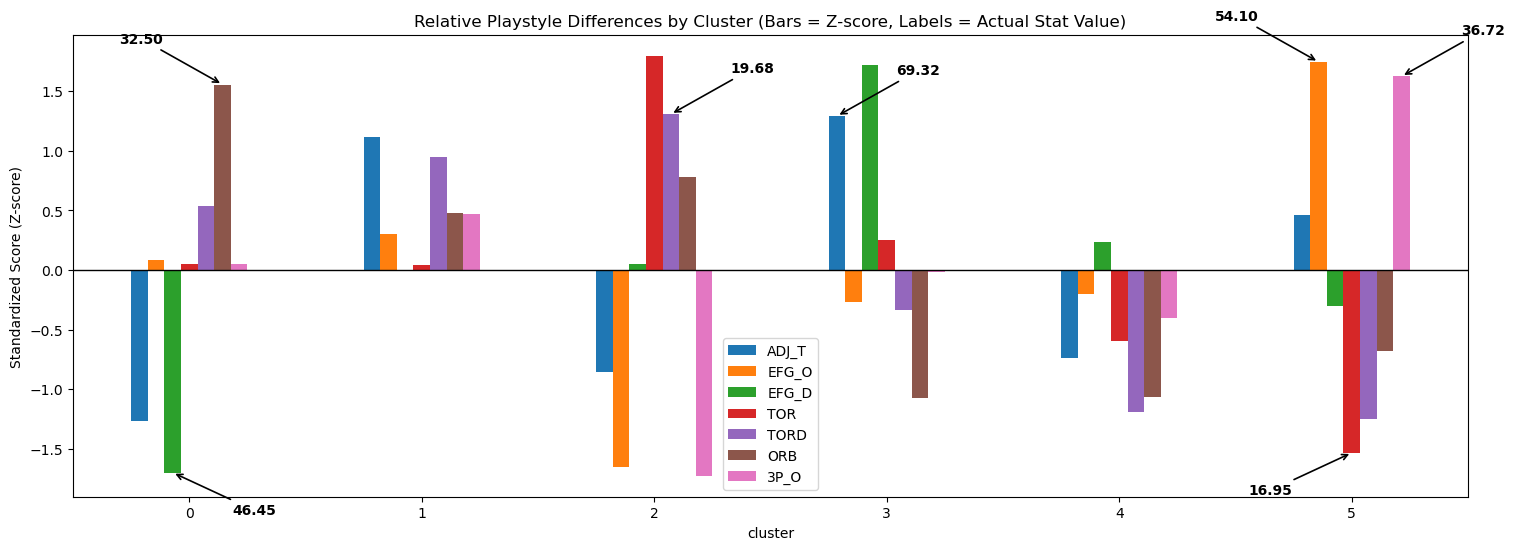

In [11]:
from sklearn.preprocessing import StandardScaler

important_stats = [
    "ADJ_T",
    "EFG_O","EFG_D",
    "TOR","TORD",
    "ORB",
    "3P_O"
]

cluster_profile = tournament_df.groupby("cluster")[important_stats].mean()

profile_scaler = StandardScaler()
cluster_scaled = profile_scaler.fit_transform(cluster_profile)

cluster_scaled = pd.DataFrame(
    cluster_scaled,
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

ax = cluster_scaled.plot(kind="bar", figsize=(18,6))

plt.title("Relative Playstyle Differences by Cluster (Bars = Z-score, Labels = Actual Stat Value)")
plt.ylabel("Standardized Score (Z-score)")
plt.xticks(rotation=0)

plt.axhline(0, color="black", linewidth=1)

# stats where LOWER is better
lower_is_better = ["EFG_D", "TOR"]

for stat_i, stat in enumerate(cluster_scaled.columns):

    if stat in lower_is_better:
        best_cluster = cluster_profile[stat].idxmin()
    else:
        best_cluster = cluster_profile[stat].idxmax()

    real_value = cluster_profile.loc[best_cluster, stat]

    container = ax.containers[stat_i]
    bar = container[best_cluster]

    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()

    x_offset = 0.35 if stat_i % 2 == 0 else -0.35
    y_offset = 0.35 if y >= 0 else -0.35

    ax.annotate(
        f"{real_value:.2f}",
        xy=(x, y),
        xytext=(x + x_offset, y + y_offset),
        ha="center",
        arrowprops=dict(arrowstyle="->", lw=1.2),
        fontsize=10,
        fontweight="bold"
    )

plt.show()

## Interpreting Playstyle Clusters (Tournament Teams)

The clustering algorithm grouped teams based on several statistical indicators that describe how teams play, including tempo, shooting efficiency, turnover rate, defensive ball pressure, rebounding, and three-point shooting. Each cluster represents a group of teams with similar statistical playstyles.

The bar chart above displays standardized (Z-score) values for the key playstyle statistics. Positive values indicate that the cluster performs above the overall average for tournament teams, while negative values indicate below-average performance.

### Cluster 0 – Slow Defensive Teams
Teams in Cluster 0 tend to play at a slower tempo and rely heavily on defensive efficiency. They allow a lower opponent effective field goal percentage than most other clusters, indicating strong defensive performance. These teams generally control the pace of the game and focus on limiting opponent scoring rather than relying on fast offensive production.

### Cluster 1 – Balanced Teams
Cluster 1 teams appear relatively balanced across most statistical categories. They do not strongly dominate any single playstyle metric but perform near the average in most areas such as tempo, shooting efficiency, turnover rate, and rebounding. These teams tend to rely on a balanced overall approach rather than one extreme style.

### Cluster 2 – Physical Rebounding Teams
Teams in Cluster 2 emphasize rebounding and physical interior play. They show the highest offensive rebounding rates among the clusters but lower shooting efficiency and slower offensive tempo. These teams often rely on second-chance opportunities and physical play near the basket to generate scoring.

### Cluster 3 – Efficient Two-Way Teams
Cluster 3 teams perform well in both offensive and defensive efficiency. They show strong effective field goal percentages on offense while also maintaining solid defensive shooting numbers. These teams tend to combine efficient offense with consistent overall play.

### Cluster 4 – Turnover-Forcing Teams
Teams in Cluster 4 stand out for their ability to pressure opponents and create mistakes. They perform well in defensive turnover rate, which suggests a playstyle built around disrupting opposing offenses. These teams often rely on defensive aggression to create extra possessions and scoring chances.

### Cluster 5 – Elite Shooting Teams
Cluster 5 teams stand out for their offensive shooting ability. They have the highest offensive effective field goal percentage and strong three-point shooting rates. These teams rely heavily on perimeter shooting and efficient offensive spacing to generate scoring opportunities.

### Summary
Overall, the clustering reveals several distinct tournament playstyles, ranging from defensive-focused teams to rebounding-heavy teams and elite shooting offenses. Later sections of this analysis examine how these playstyles relate to tournament success and advancement through the NCAA Tournament.

In [12]:
round_table = pd.crosstab(df_model["cluster"], df_model["POSTSEASON"])

round_table

POSTSEASON,2ND,Champions,E8,F4,R32,R64,R68,S16
cluster,,,,,,,,
0,4,4,17,9,82,127,11,42
1,0,0,7,1,22,76,16,4
2,0,0,0,0,1,8,3,1
3,0,0,0,0,1,1,1,0
4,0,0,1,1,9,14,6,1
5,7,7,19,11,61,126,7,40


In [13]:
round_order = [
    "R68",
    "R64",
    "R32",
    "S16",
    "E8",
    "F4",
    "2ND",
    "Champions"
]

round_table = round_table.reindex(columns=round_order)

round_table = round_table.fillna(0)

round_table

POSTSEASON,R68,R64,R32,S16,E8,F4,2ND,Champions
cluster,,,,,,,,
0,11,127,82,42,17,9,4,4
1,16,76,22,4,7,1,0,0
2,3,8,1,1,0,0,0,0
3,1,1,1,0,0,0,0,0
4,6,14,9,1,1,1,0,0
5,7,126,61,40,19,11,7,7


In [14]:
round_table["Total Teams"] = round_table.sum(axis=1)

round_table

POSTSEASON,R68,R64,R32,S16,E8,F4,2ND,Champions,Total Teams
cluster,,,,,,,,,
0,11,127,82,42,17,9,4,4,296
1,16,76,22,4,7,1,0,0,126
2,3,8,1,1,0,0,0,0,13
3,1,1,1,0,0,0,0,0,3
4,6,14,9,1,1,1,0,0,32
5,7,126,61,40,19,11,7,7,278


### Postseason Note

The `POSTSEASON` column shows the **furthest round each team reached** in that season’s NCAA Tournament.  
Each team appears only once, based on its final finish (`R68`, `R64`, `R32`, `S16`, `E8`, `F4`, `2ND`, or `Champions`).

Because of that, the round table shows **where teams finished**, not every round they played.

In [15]:
success_rates = round_table.copy()

rounds = ["R68","R64","R32","S16","E8","F4","2ND","Champions"]

for r in rounds:
    success_rates[r + "_share"] = (
        success_rates[r] / success_rates[r].sum() * 100
    ).round(1)

success_rates

POSTSEASON,R68,R64,R32,S16,E8,F4,2ND,Champions,Total Teams,R68_share,R64_share,R32_share,S16_share,E8_share,F4_share,2ND_share,Champions_share
cluster,,,,,,,,,,,,,,,,,
0,11,127,82,42,17,9,4,4,296,25.0,36.1,46.6,47.7,38.6,40.9,36.4,36.4
1,16,76,22,4,7,1,0,0,126,36.4,21.6,12.5,4.5,15.9,4.5,0.0,0.0
2,3,8,1,1,0,0,0,0,13,6.8,2.3,0.6,1.1,0.0,0.0,0.0,0.0
3,1,1,1,0,0,0,0,0,3,2.3,0.3,0.6,0.0,0.0,0.0,0.0,0.0
4,6,14,9,1,1,1,0,0,32,13.6,4.0,5.1,1.1,2.3,4.5,0.0,0.0
5,7,126,61,40,19,11,7,7,278,15.9,35.8,34.7,45.5,43.2,50.0,63.6,63.6


In [16]:
success_summary = success_rates[[
    "Total Teams",
    "R64_share",
    "R32_share",
    "S16_share",
    "E8_share",
    "F4_share",
    "2ND_share",
    "Champions_share"
]]

success_summary

POSTSEASON,Total Teams,R64_share,R32_share,S16_share,E8_share,F4_share,2ND_share,Champions_share
cluster,,,,,,,,
0,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4
1,126,21.6,12.5,4.5,15.9,4.5,0.0,0.0
2,13,2.3,0.6,1.1,0.0,0.0,0.0,0.0
3,3,0.3,0.6,0.0,0.0,0.0,0.0,0.0
4,32,4.0,5.1,1.1,2.3,4.5,0.0,0.0
5,278,35.8,34.7,45.5,43.2,50.0,63.6,63.6


In [17]:
success_summary.style.format({
    "Total Teams": "{:.0f}",
    "R64_share": "{:.1f}%",
    "R32_share": "{:.1f}%",
    "S16_share": "{:.1f}%",
    "E8_share": "{:.1f}%",
    "F4_share": "{:.1f}%",
    "2ND_share": "{:.1f}%",
    "Champions_share": "{:.1f}%"
})



POSTSEASON,Total Teams,R64_share,R32_share,S16_share,E8_share,F4_share,2ND_share,Champions_share
cluster,,,,,,,,
0,296,36.1%,46.6%,47.7%,38.6%,40.9%,36.4%,36.4%
1,126,21.6%,12.5%,4.5%,15.9%,4.5%,0.0%,0.0%
2,13,2.3%,0.6%,1.1%,0.0%,0.0%,0.0%,0.0%
3,3,0.3%,0.6%,0.0%,0.0%,0.0%,0.0%,0.0%
4,32,4.0%,5.1%,1.1%,2.3%,4.5%,0.0%,0.0%
5,278,35.8%,34.7%,45.5%,43.2%,50.0%,63.6%,63.6%


In [18]:
cluster_sizes = df_model["cluster"].value_counts().sort_index()

cluster_success_rate = pd.DataFrame({
    "Teams_in_cluster": cluster_sizes,
    "Sweet_16": round_table["S16"],
    "Elite_8": round_table["E8"],
    "Final_Four": round_table["F4"],
    "Champions": round_table["Champions"]
})

cluster_success_rate["Sweet16_rate"] = (
    cluster_success_rate["Sweet_16"] /
    cluster_success_rate["Teams_in_cluster"] * 100
).round(2)

cluster_success_rate["Elite8_rate"] = (
    cluster_success_rate["Elite_8"] /
    cluster_success_rate["Teams_in_cluster"] * 100
).round(2)

cluster_success_rate["Final4_rate"] = (
    cluster_success_rate["Final_Four"] /
    cluster_success_rate["Teams_in_cluster"] * 100
).round(2)

cluster_success_rate["Champion_rate"] = (
    cluster_success_rate["Champions"] /
    cluster_success_rate["Teams_in_cluster"] * 100
).round(2)

cluster_success_rate = cluster_success_rate[[
    "Teams_in_cluster",
    "Sweet_16", "Sweet16_rate",
    "Elite_8", "Elite8_rate",
    "Final_Four", "Final4_rate",
    "Champions", "Champion_rate"
]]

cluster_success_rate

,Teams_in_cluster,Sweet_16,Sweet16_rate,Elite_8,Elite8_rate,Final_Four,Final4_rate,Champions,Champion_rate
cluster,,,,,,,,,
0,713,42,5.89,17,2.38,9,1.26,4,0.56
1,669,4,0.60,7,1.05,1,0.15,0,0.00
2,638,1,0.16,0,0.00,0,0.00,0,0.00
3,547,0,0.00,0,0.00,0,0.00,0,0.00
4,665,1,0.15,1,0.15,1,0.15,0,0.00
5,653,40,6.13,19,2.91,11,1.68,7,1.07


### Tournament Success Rates Within Each Cluster

The tables above show how much each cluster contributes to different tournament rounds, such as the Sweet 16, Final Four, and national champions. However, those tables do not account for the fact that some clusters contain more teams than others.

To address that, the table below calculates success rates within each cluster. This shows the percentage of teams in each cluster that reached major tournament milestones, including the Sweet 16, Elite Eight, Final Four, and national championship.

This view is useful because it measures how successful each playstyle has been relative to its size. In other words, it helps answer the question: if a team belongs to a certain playstyle cluster, how often does that type of team make a deep NCAA Tournament run?

## 8. Applying Model to 2026 Teams

In [19]:
torvik_raw = pd.read_excel("torvik_2026.xlsx")

# Fix the shifted columns caused by the pasted sheet format
torvik_df = torvik_raw.rename(columns={
    "Conf": "TEAM",
    "G": "CONF",
    "Rec": "G",
    "AdjOE": "Rec",
    "AdjDE": "ADJOE",
    "Barthag": "ADJDE",
    "EFG%": "BARTHAG",
    "EFGD%": "EFG_O",
    "TOR": "EFG_D",
    "TORD": "TOR",
    "ORB": "TORD",
    "DRB": "ORB",
    "FTR": "DRB",
    "FTRD": "FTR",
    "2P%": "FTRD",
    "2P%D": "2P_O",
    "3P%": "2P_D",
    "3P%D": "3P_O",
    "3PR": "3P_D",
    "3PRD": "3PR",
    "Adj T.": "3PRD",
    "WAB": "ADJ_T"
}).copy()

# Keep only real team rows
torvik_df = torvik_df[torvik_df["TEAM"].notna()].copy()
torvik_df = torvik_df[torvik_df["TEAM"] != "Team"].copy()
torvik_df = torvik_df[~torvik_df["TEAM"].astype(str).str.contains("seed", case=False, na=False)].copy()
torvik_df = torvik_df.reset_index(drop=True)

# Convert model features to numeric
for col in features:
    torvik_df[col] = pd.to_numeric(torvik_df[col], errors="coerce")

print("Rows after cleaning:", torvik_df.shape[0])
torvik_df[["TEAM", "CONF"] + features[:5]].head()

Rows after cleaning: 368


,TEAM,CONF,ADJ_T,EFG_O,EFG_D,TOR,TORD
0,Duke,ACC,65.8,56.8,46.2,15.7,18.1
1,Michigan,B10,71.2,58.1,44.7,16.7,15.5
2,Arizona,B12,70.0,55.1,45.0,15.1,16.7
3,Florida,SEC,70.4,53.5,46.3,16.5,15.4
4,Houston,B12,63.3,52.1,46.6,13.0,21.0


Stats as of 3/15/2026 8:52 pm cst

In [20]:
current_X = torvik_df[features].dropna()
print("Teams surviving model features:", current_X.shape[0])
current_X.head()

Teams surviving model features: 368


,ADJ_T,EFG_O,EFG_D,TOR,TORD,ORB,DRB,FTR,FTRD,2P_O,2P_D,3P_O,3P_D
0,65.8,56.8,46.2,15.7,18.1,38.1,24.8,37.8,23.7,60.1,46.6,35.1,30.4
1,71.2,58.1,44.7,16.7,15.5,35.4,27.7,37.7,26.3,61.0,44.3,36.0,30.2
2,70.0,55.1,45.0,15.1,16.7,38.1,26.9,42.9,27.7,55.4,43.8,36.0,31.4
3,70.4,53.5,46.3,16.5,15.4,43.2,24.8,39.1,34.0,57.9,45.2,30.8,32.4
4,63.3,52.1,46.6,13.0,21.0,35.9,30.9,26.9,39.0,51.9,45.5,34.9,32.1


In [21]:
torvik_clean = torvik_df.loc[current_X.index].copy()
print("torvik_clean rows:", torvik_clean.shape[0])

torvik_clean rows: 368


In [22]:
current_scaled = scaler.transform(current_X)

In [23]:
torvik_clean["cluster"] = kmeans.predict(current_scaled)
torvik_clean[["TEAM", "CONF", "cluster"]].head(15)

,TEAM,CONF,cluster
0,Duke,ACC,5
1,Michigan,B10,5
2,Arizona,B12,0
3,Florida,SEC,0
4,Houston,B12,0
5,Illinois,B10,5
6,Iowa St.,B12,5
7,Purdue,B10,5
8,Connecticut,BE,0
9,Vanderbilt,SEC,5


In [24]:
current_pcs = pca.transform(current_scaled)
torvik_clean["PC1"] = current_pcs[:, 0]
torvik_clean["PC2"] = current_pcs[:, 1]

torvik_clean[["TEAM", "CONF", "cluster", "PC1", "PC2"]].head(15)

,TEAM,CONF,cluster,PC1,PC2
0,Duke,ACC,5,4.272124,-2.538314
1,Michigan,B10,5,4.661376,-2.522964
2,Arizona,B12,0,3.310739,-2.970139
3,Florida,SEC,0,2.265603,-2.722089
4,Houston,B12,0,1.380399,-2.168080
5,Illinois,B10,5,4.557698,-1.196547
6,Iowa St.,B12,5,3.035271,-0.771011
7,Purdue,B10,5,4.322237,1.032538
8,Connecticut,BE,0,2.543697,-2.558663
9,Vanderbilt,SEC,5,2.317126,-0.697887


In [25]:
torvik_results = torvik_clean.merge(
    success_summary,
    left_on="cluster",
    right_index=True,
    how="left"
)

torvik_results.head(15)

,Rk,Team,TEAM,CONF,G,Rec,ADJOE,ADJDE,BARTHAG,EFG_O,...,PC1,PC2,Total Teams,R64_share,R32_share,S16_share,E8_share,F4_share,2ND_share,Champions_share
0,NaN,1,Duke,ACC,34,32-2,128.1,90.8,0.9813,56.8,...,4.272124,-2.538314,278,35.8,34.7,45.5,43.2,50.0,63.6,63.6
1,NaN,2,Michigan,B10,34,31-3,127.6,91,0.9799,58.1,...,4.661376,-2.522964,278,35.8,34.7,45.5,43.2,50.0,63.6,63.6
2,NaN,3,Arizona,B12,34,32-2,126.9,91.4,0.9776,55.1,...,3.310739,-2.970139,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4
3,NaN,4,Florida,SEC,33,26-7,126.1,92.3,0.9732,53.5,...,2.265603,-2.722089,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4
4,NaN,5,Houston,B12,34,28-6,125.4,92.4,0.971,52.1,...,1.380399,-2.168080,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4
5,NaN,6,Illinois,B10,32,24-8,131.9,98.2,0.9676,55.1,...,4.557698,-1.196547,278,35.8,34.7,45.5,43.2,50.0,63.6,63.6
6,NaN,7,Iowa St.,B12,34,27-7,123.8,92.6,0.9655,56.5,...,3.035271,-0.771011,278,35.8,34.7,45.5,43.2,50.0,63.6,63.6
7,NaN,8,Purdue,B10,35,27-8,133.3,100.3,0.9636,57.6,...,4.322237,1.032538,278,35.8,34.7,45.5,43.2,50.0,63.6,63.6
8,NaN,9,Connecticut,BE,34,29-5,123.1,95,0.9518,55.3,...,2.543697,-2.558663,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4
9,NaN,10,Vanderbilt,SEC,34,26-8,127.4,99.3,0.9461,55.3,...,2.317126,-0.697887,278,35.8,34.7,45.5,43.2,50.0,63.6,63.6


In [26]:
actual_tourney_teams = [
    # EAST
    "Duke", "Siena", "Ohio St.", "TCU", "St. John's", "Northern Iowa",
    "Kansas", "Cal Baptist", "Louisville", "South Florida", "Michigan St.",
    "North Dakota St.", "UCLA", "UCF", "UConn", "Connecticut", "Furman",

    # SOUTH
    "Florida", "Lehigh", "Prairie View A&M", "PVAMU", "Clemson", "Iowa",
    "Vanderbilt", "McNeese", "McNeese St.", "Nebraska", "Troy",
    "North Carolina", "VCU", "Illinois", "Penn", "Saint Mary's",
    "Texas A&M", "Houston", "Idaho",

    # WEST
    "Arizona", "Long Island", "LIU", "Villanova", "Utah St.", "Wisconsin",
    "High Point", "Arkansas", "Hawaii", "BYU", "NC State", "N.C. State",
    "Texas", "Gonzaga", "Kennesaw St.", "Miami FL", "Missouri", "Purdue",
    "Queens", "Queens (N.C.)",

    # MIDWEST
    "Michigan", "Howard", "UMBC", "Georgia", "Saint Louis", "Texas Tech",
    "Akron", "Alabama", "Hofstra", "Tennessee", "SMU", "Miami OH",
    "Virginia", "Wright St.", "Kentucky", "Santa Clara", "Iowa St.",
    "Tennessee St."
]

torvik_plot = torvik_results[
    torvik_results["TEAM"].isin(actual_tourney_teams)
].copy()

print("Teams found:", torvik_plot.shape[0])
print(sorted(torvik_plot["TEAM"].unique()))

Teams found: 68
['Akron', 'Alabama', 'Arizona', 'Arkansas', 'BYU', 'Cal Baptist', 'Clemson', 'Connecticut', 'Duke', 'Florida', 'Furman', 'Georgia', 'Gonzaga', 'Hawaii', 'High Point', 'Hofstra', 'Houston', 'Howard', 'Idaho', 'Illinois', 'Iowa', 'Iowa St.', 'Kansas', 'Kennesaw St.', 'Kentucky', 'LIU', 'Lehigh', 'Louisville', 'McNeese St.', 'Miami FL', 'Miami OH', 'Michigan', 'Michigan St.', 'Missouri', 'N.C. State', 'Nebraska', 'North Carolina', 'North Dakota St.', 'Northern Iowa', 'Ohio St.', 'Penn', 'Prairie View A&M', 'Purdue', 'Queens', 'SMU', 'Saint Louis', "Saint Mary's", 'Santa Clara', 'Siena', 'South Florida', "St. John's", 'TCU', 'Tennessee', 'Tennessee St.', 'Texas', 'Texas A&M', 'Texas Tech', 'Troy', 'UCF', 'UCLA', 'UMBC', 'Utah St.', 'VCU', 'Vanderbilt', 'Villanova', 'Virginia', 'Wisconsin', 'Wright St.']


In [27]:
torvik_df.columns

Index(['Rk', 'Team', 'TEAM', 'CONF', 'G', 'Rec', 'ADJOE', 'ADJDE', 'BARTHAG',
       'EFG_O', 'EFG_D', 'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O',
       '2P_D', '3P_O', '3P_D', '3PR', '3PRD', 'ADJ_T'],
      dtype='object')

C:\Users\klara\AppData\Local\Temp\ipykernel_25104\2560557882.py:20: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.scatterplot(


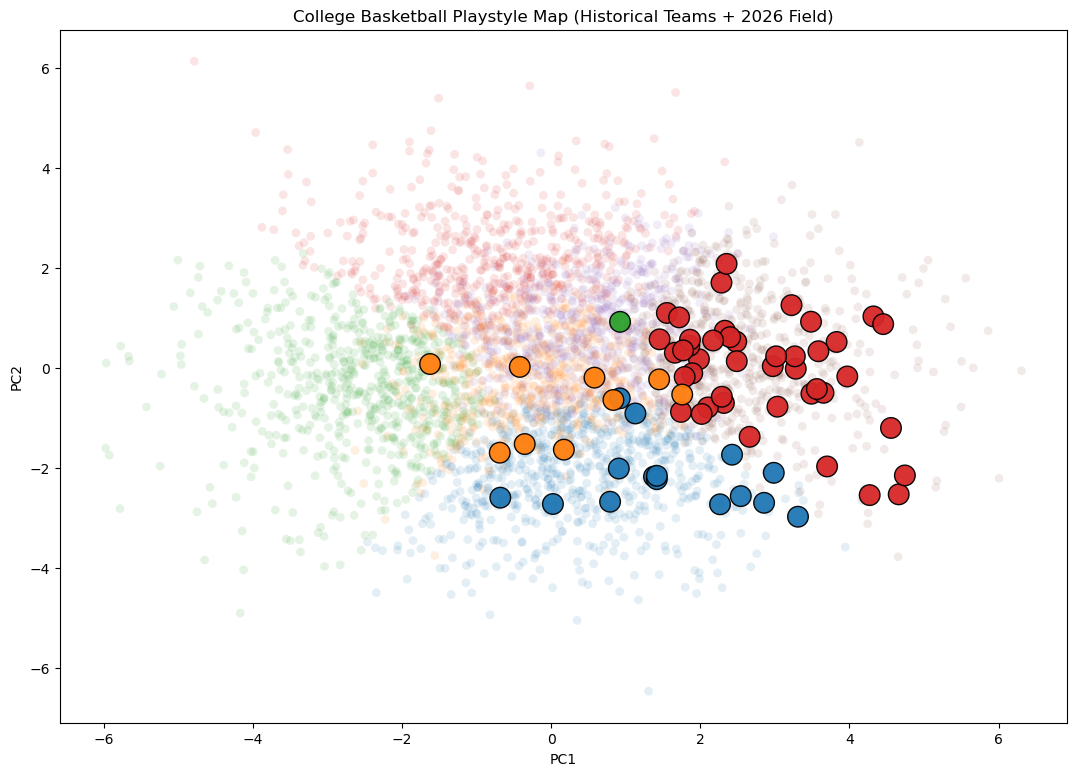

In [28]:
plt.figure(figsize=(13,9))
ax = plt.gca()


palette = sns.color_palette("tab10", 6)

# Historical teams (background)
sns.scatterplot(
    data=df_model,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=palette,
    alpha=0.12,
    legend=False,
    s=40
)

# 2026 teams (foreground)
sns.scatterplot(
    data=torvik_plot,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette=palette,
    s=220,
    edgecolor="black",
    linewidth=1.0,
    alpha=0.95,
    legend=False
)




plt.title("College Basketball Playstyle Map (Historical Teams + 2026 Field)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [29]:
torvik_plot["cluster"].value_counts().sort_index()

cluster
0    15
1     9
4     1
5    43
Name: count, dtype: int64

In [30]:
torvik_plot[["TEAM", "CONF", "cluster", "Champions_share", "F4_share"]].sort_values(
    ["cluster", "Champions_share"], ascending=[True, False]
)

,TEAM,CONF,cluster,Champions_share,F4_share
2,Arizona,B12,0,36.4,40.9
3,Florida,SEC,0,36.4,40.9
4,Houston,B12,0,36.4,40.9
8,Connecticut,BE,0,36.4,40.9
13,Virginia,ACC,0,36.4,40.9
...,...,...,...,...,...
138,Idaho,BSky,5,63.6,50.0
187,UMBC,AE,5,63.6,50.0
196,Furman,SC,5,63.6,50.0
200,Queens,ASun,5,63.6,50.0


## 9. Identifying Championship Profiles

In [31]:
champions_df = df_model[df_model["POSTSEASON"] == "Champions"].copy()

champions_df[["TEAM","YEAR","PC1","PC2"]]

,TEAM,YEAR,PC1,PC2
7,Duke,2015,3.460965,-2.202479
8,Virginia,2019,4.199696,-2.415420
9,North Carolina,2017,1.546850,-1.548371
10,Villanova,2016,3.095198,-1.414352
11,Villanova,2018,5.126524,-0.077600
12,Connecticut,2014,0.839320,-2.830803
13,Louisville,2013,-0.734546,-3.970815
2456,Baylor,2021,2.499826,-0.889944
2803,Kansas,2022,2.630854,-1.969686
3172,Connecticut,2023,2.107966,-3.369587


In [32]:
champion_center = champions_df[["PC1","PC2"]].mean()

champion_center

PC1    2.630664
PC2   -2.120941
dtype: float64

In [33]:
from sklearn.preprocessing import StandardScaler
import numpy as np

pc_scaler = StandardScaler()

champion_pcs_scaled = pc_scaler.fit_transform(champions_df[["PC1", "PC2"]])
champion_center_scaled = champion_pcs_scaled.mean(axis=0)

current_pcs_scaled = pc_scaler.transform(torvik_plot[["PC1", "PC2"]])

torvik_plot["champion_distance"] = np.sqrt(
    (current_pcs_scaled[:, 0] - champion_center_scaled[0])**2 +
    (current_pcs_scaled[:, 1] - champion_center_scaled[1])**2
)

In [34]:
champion_similarity = torvik_plot.sort_values("champion_distance")

champion_similarity[
    ["TEAM","CONF","cluster","champion_distance"]
].head(20)

,TEAM,CONF,cluster,champion_distance
24,Saint Mary's,WCC,0,0.224551
21,Kansas,B12,0,0.389090
8,Connecticut,BE,0,0.416035
13,Virginia,ACC,0,0.556608
3,Florida,SEC,0,0.610980
10,Gonzaga,WCC,5,0.687269
12,Michigan St.,B10,5,0.704736
118,Hawaii,BW,0,0.761052
92,Hofstra,CAA,0,0.766403
4,Houston,B12,0,0.785630


In [35]:
champion_contenders = champion_similarity[
    champion_similarity["BARTHAG"] >= 0.900
]

champion_contenders.head(15)

,Rk,Team,TEAM,CONF,G,Rec,ADJOE,ADJDE,BARTHAG,EFG_O,...,PC2,Total Teams,R64_share,R32_share,S16_share,E8_share,F4_share,2ND_share,Champions_share,champion_distance
24,NaN,25,Saint Mary's,WCC,32,27-5,119.4,97.6,0.9104,52.9,...,-2.093065,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4,0.224551
21,NaN,22,Kansas,B12,33,23-10,117.9,94.4,0.9279,51.6,...,-1.730989,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4,0.389090
8,NaN,9,Connecticut,BE,34,29-5,123.1,95,0.9518,55.3,...,-2.558663,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4,0.416035
13,NaN,14,Virginia,ACC,34,29-5,122.2,95.8,0.9427,54.6,...,-2.692268,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4,0.556608
3,NaN,4,Florida,SEC,33,26-7,126.1,92.3,0.9732,53.5,...,-2.722089,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4,0.610980
10,NaN,11,Gonzaga,WCC,33,30-3,120.3,94,0.9444,56.3,...,-1.965947,278,35.8,34.7,45.5,43.2,50.0,63.6,63.6,0.687269
12,NaN,13,Michigan St.,B10,32,25-7,122.9,96.2,0.9438,53.6,...,-1.373309,278,35.8,34.7,45.5,43.2,50.0,63.6,63.6,0.704736
4,NaN,5,Houston,B12,34,28-6,125.4,92.4,0.971,52.1,...,-2.168080,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4,0.785630
2,NaN,3,Arizona,B12,34,32-2,126.9,91.4,0.9776,55.1,...,-2.970139,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4,0.906797
14,NaN,15,St. John's,BE,34,28-6,119.8,94.1,0.9414,51.0,...,-2.007367,296,36.1,46.6,47.7,38.6,40.9,36.4,36.4,1.085897


In [36]:
# smaller distance = better, so convert to similarity
torvik_plot["champion_similarity"] = 1 / (1 + torvik_plot["champion_distance"])

# optional normalized version
torvik_plot["champion_similarity_norm"] = (
    (torvik_plot["champion_similarity"] - torvik_plot["champion_similarity"].min()) /
    (torvik_plot["champion_similarity"].max() - torvik_plot["champion_similarity"].min())
)

In [37]:
torvik_plot["cluster_strength"] = (
    torvik_plot["Champions_share"] * 0.7 +
    torvik_plot["F4_share"] * 0.3
)

In [38]:
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

torvik_plot["BARTHAG_norm"] = minmax(torvik_plot["BARTHAG"])
torvik_plot["cluster_strength_norm"] = minmax(torvik_plot["cluster_strength"])

In [39]:
torvik_plot["Champion_Score"] = (
    torvik_plot["champion_similarity_norm"] * 0.45 +
    torvik_plot["BARTHAG_norm"] * 0.40 +
    torvik_plot["cluster_strength_norm"] * 0.15
)

champion_ranking = torvik_plot.sort_values("Champion_Score", ascending=False).copy()

champion_ranking[
    ["TEAM", "CONF", "cluster", "BARTHAG", "champion_distance", "Champion_Score"]
].head(25)

,TEAM,CONF,cluster,BARTHAG,champion_distance,Champion_Score
24,Saint Mary's,WCC,0,0.9104,0.224551,0.904992
8,Connecticut,BE,0,0.9518,0.416035,0.846908
21,Kansas,B12,0,0.9279,0.389090,0.843826
10,Gonzaga,WCC,5,0.9444,0.687269,0.815943
12,Michigan St.,B10,5,0.9438,0.704736,0.811171
3,Florida,SEC,0,0.9732,0.610980,0.796126
13,Virginia,ACC,0,0.9427,0.556608,0.795266
0,Duke,ACC,5,0.9813,1.102333,0.750576
4,Houston,B12,0,0.971,0.785630,0.750506
2,Arizona,B12,0,0.9776,0.906797,0.728092


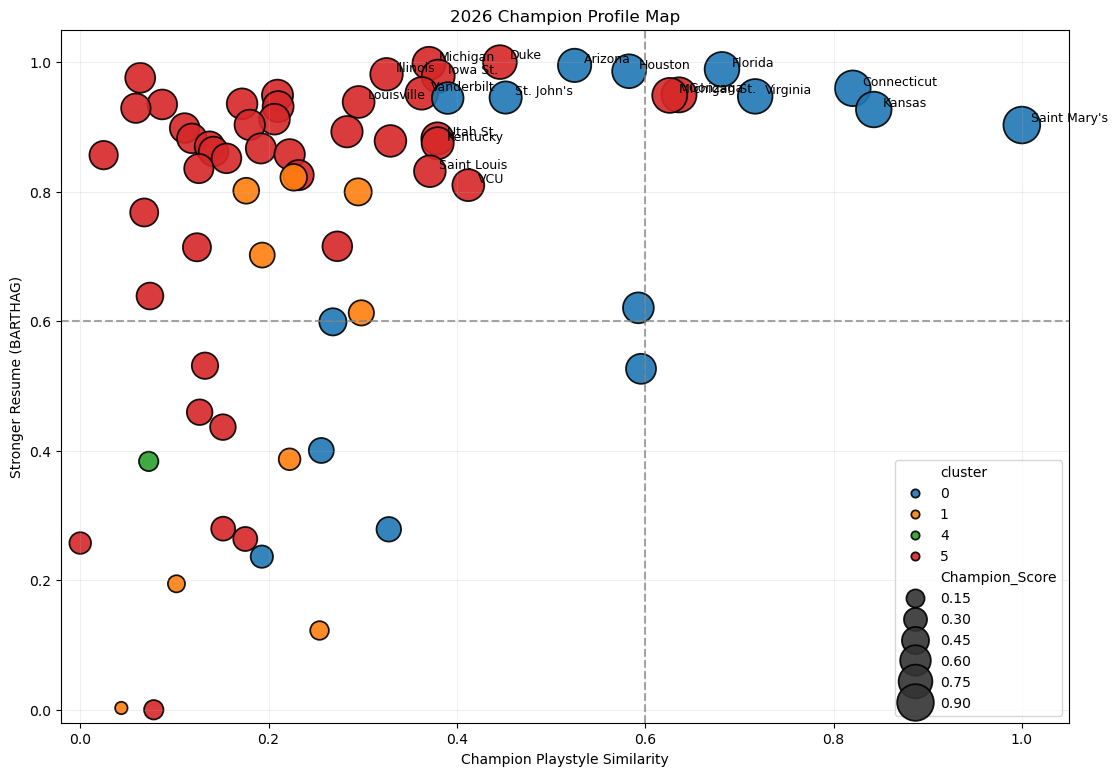

In [40]:
plt.figure(figsize=(13,9))
ax = plt.gca()

sns.scatterplot(
    data=torvik_plot,
    x="champion_similarity_norm",
    y="BARTHAG_norm",
    hue="cluster",
    size="Champion_Score",
    sizes=(80, 700),
    palette="tab10",
    edgecolor="black",
    alpha=0.9
)

# label top teams
top_labels = torvik_plot.sort_values("Champion_Score", ascending=False).head(20)

for _, row in top_labels.iterrows():
    ax.text(
        row["champion_similarity_norm"] + 0.01,
        row["BARTHAG_norm"] + 0.005,
        row["TEAM"],
        fontsize=9
    )

plt.axvline(0.6, linestyle="--", color="gray", alpha=0.7)
plt.axhline(0.6, linestyle="--", color="gray", alpha=0.7)

plt.title("2026 Champion Profile Map")
plt.xlabel("Champion Playstyle Similarity")
plt.ylabel("Stronger Resume (BARTHAG)")
plt.xlim(-0.02, 1.05)
plt.ylim(-0.02, 1.05)
plt.grid(alpha=0.2)

plt.show()

### Champion Profile Map (2026 Teams)

This chart compares current 2026 teams to the statistical profile of historical NCAA champions.

Each team is evaluated using three key indicators:

- **Champion Similarity (x-axis)** — how similar the team’s playstyle is to historical champions based on PCA distance.
- **BARTHAG (y-axis)** — an overall team strength metric based on adjusted offensive and defensive efficiency.
- **Champion Score (circle size)** — a combined metric using champion similarity, team strength, and the historical success of the team’s playstyle cluster.

Teams appearing toward the upper-right corner of the chart are both:

- statistically similar to past championship teams
- and strong overall teams based on efficiency metrics.

These teams represent the strongest championship candidates entering the NCAA Tournament.

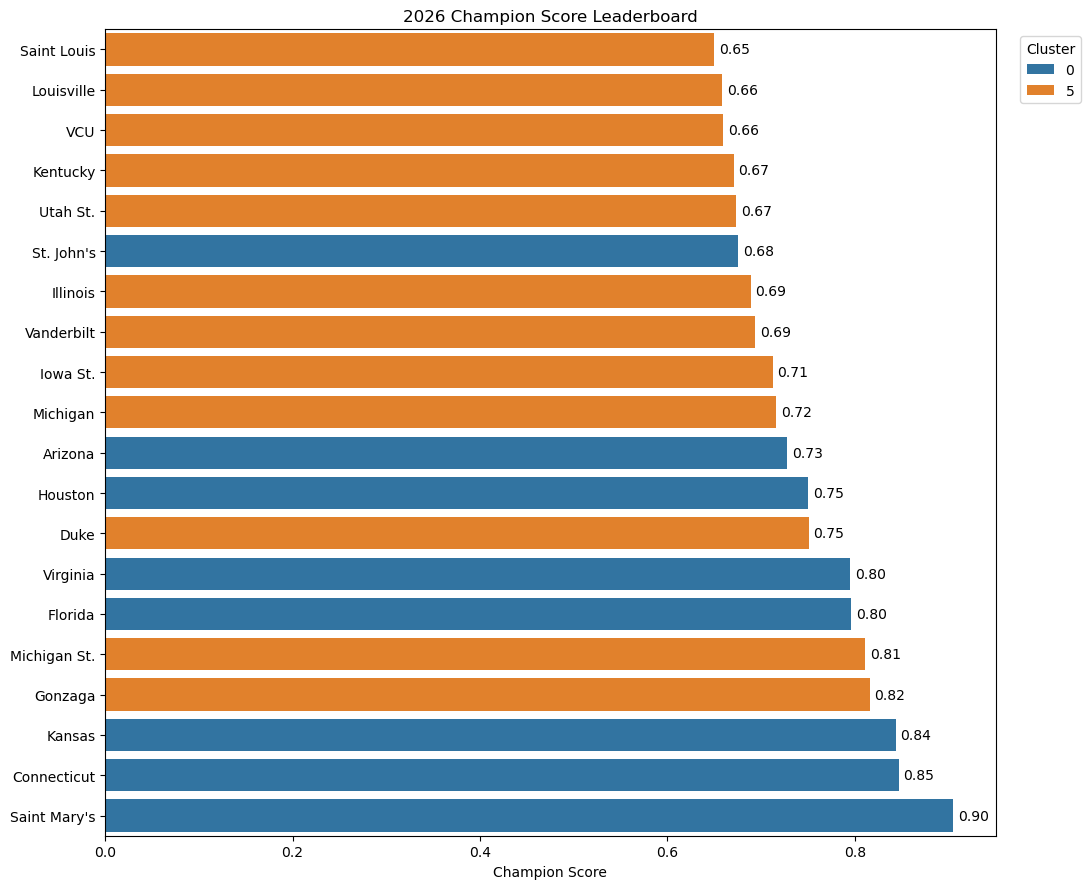

In [41]:
top_n = 20
leaderboard = champion_ranking.head(top_n).sort_values("Champion_Score", ascending=True)

plt.figure(figsize=(11,9))
ax = plt.gca()

sns.barplot(
    data=leaderboard,
    x="Champion_Score",
    y="TEAM",
    hue="cluster",
    dodge=False,
    palette="tab10"
)

# add score labels
for i, row in leaderboard.iterrows():
    ax.text(
        row["Champion_Score"] + 0.005,
        leaderboard.index.get_loc(i),
        f"{row['Champion_Score']:.2f}",
        va="center"
    )

plt.title("2026 Champion Score Leaderboard")
plt.xlabel("Champion Score")
plt.ylabel("")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [42]:
champion_ranking[
    ["TEAM","BARTHAG","champion_similarity_norm","cluster_strength_norm","Champion_Score"]
].head(15)

,TEAM,BARTHAG,champion_similarity_norm,cluster_strength_norm,Champion_Score
24,Saint Mary's,0.9104,1.000000,0.625752,0.904992
8,Connecticut,0.9518,0.820485,0.625752,0.846908
21,Kansas,0.9279,0.842754,0.625752,0.843826
10,Gonzaga,0.9444,0.635940,1.000000,0.815943
12,Michigan St.,0.9438,0.626068,1.000000,0.811171
3,Florida,0.9732,0.681565,0.625752,0.796126
13,Virginia,0.9427,0.716812,0.625752,0.795266
0,Duke,0.9813,0.445724,1.000000,0.750576
4,Houston,0.971,0.582868,0.625752,0.750506
2,Arizona,0.9776,0.525018,0.625752,0.728092


In [43]:
df_model["is_champion"] = df_model["POSTSEASON"] == "Champions"
df_model["is_final4"] = df_model["POSTSEASON"].isin(["Champions", "2ND", "F4"])

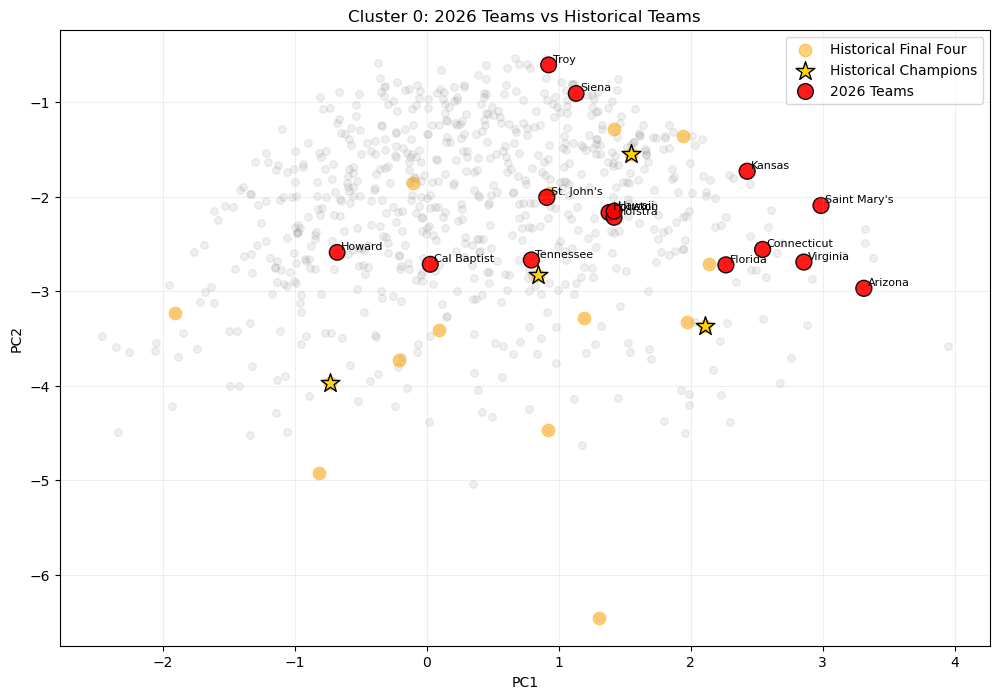

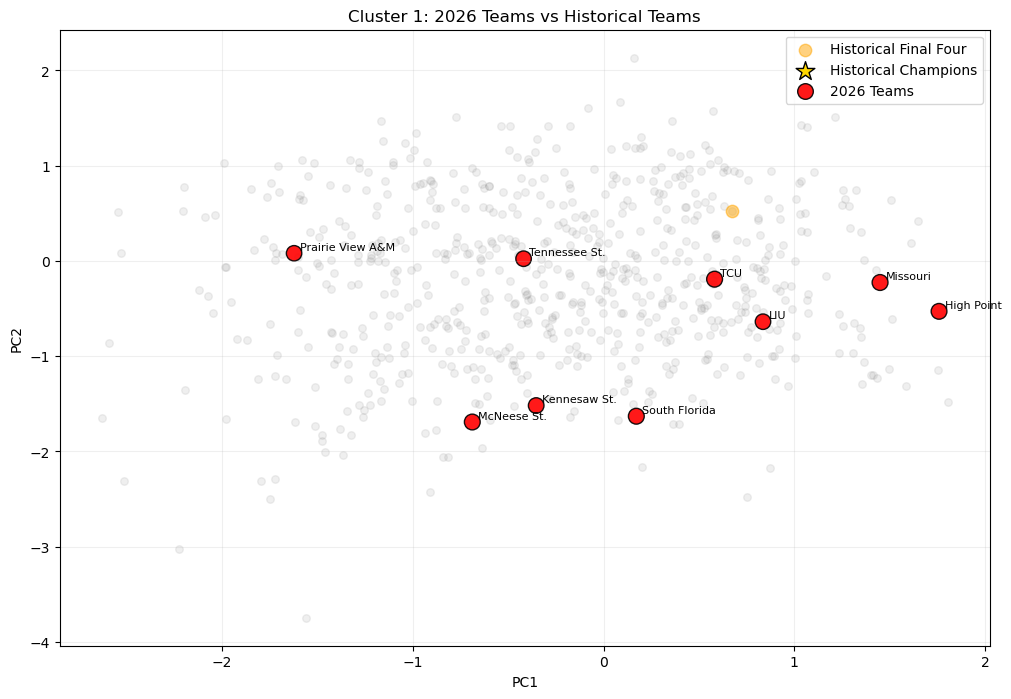

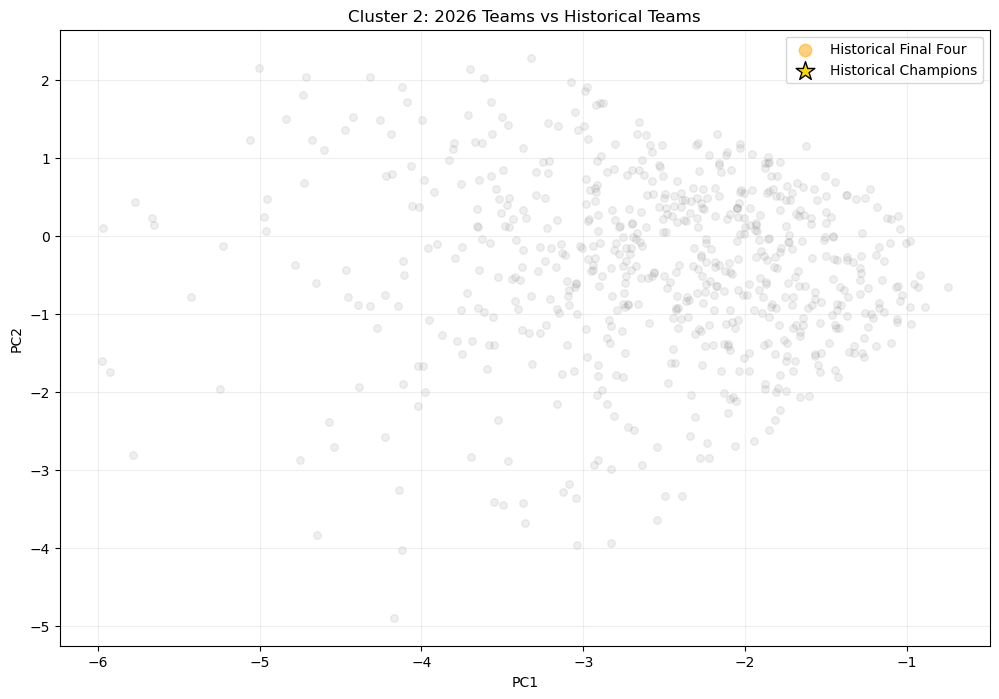

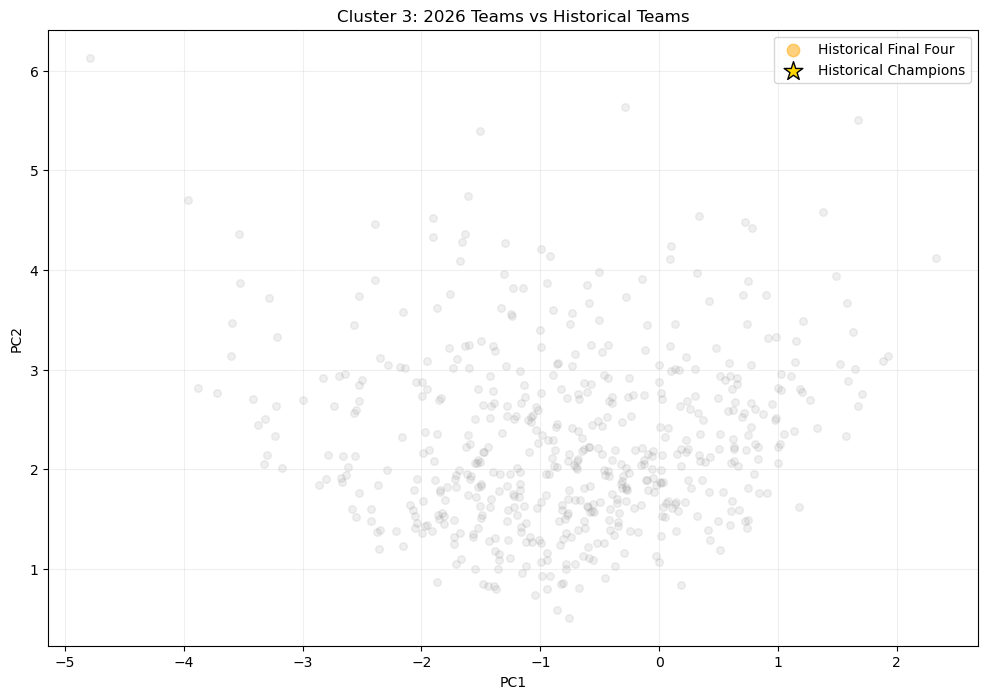

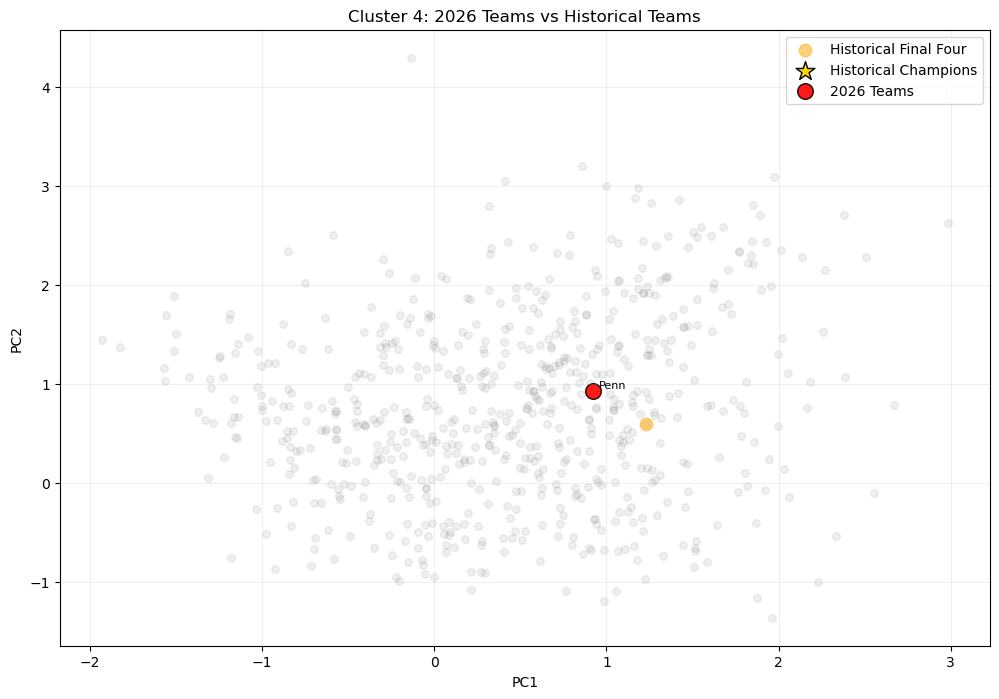

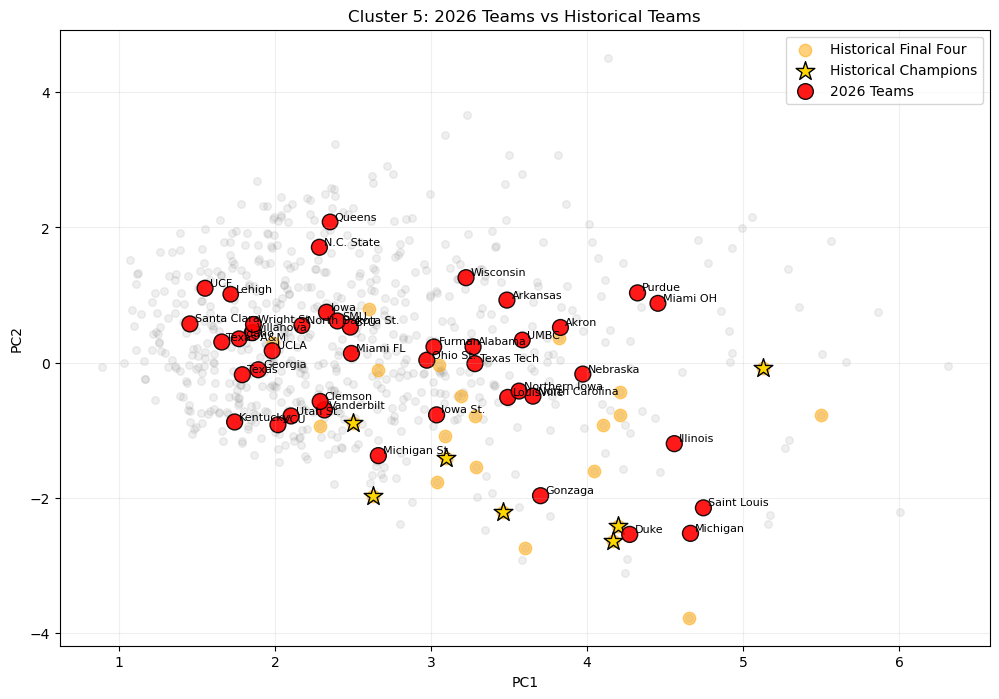

In [44]:
for cluster_id in sorted(df_model["cluster"].unique()):

    hist_cluster = df_model[df_model["cluster"] == cluster_id].copy()
    current_cluster = torvik_plot[torvik_plot["cluster"] == cluster_id].copy()

    plt.figure(figsize=(12, 8))
    ax = plt.gca()

    # all historical teams in cluster
    plt.scatter(
        hist_cluster["PC1"],
        hist_cluster["PC2"],
        s=30,
        alpha=0.12,
        color="gray"
    )

    # historical Final Four teams
    hist_f4 = hist_cluster[hist_cluster["POSTSEASON"].isin(["Champions", "2ND", "F4"])]
    plt.scatter(
        hist_f4["PC1"],
        hist_f4["PC2"],
        s=80,
        alpha=0.5,
        color="orange",
        label="Historical Final Four"
    )

    # historical champions
    hist_champs = hist_cluster[hist_cluster["POSTSEASON"] == "Champions"]
    plt.scatter(
        hist_champs["PC1"],
        hist_champs["PC2"],
        s=200,
        color="gold",
        edgecolor="black",
        marker="*",
        label="Historical Champions"
    )

    # make sure BARTHAG is numeric before using it for point sizes
    current_cluster["BARTHAG"] = pd.to_numeric(current_cluster["BARTHAG"], errors="coerce")
    point_sizes = (120 + current_cluster["BARTHAG"].fillna(0).clip(lower=0) * 12).to_numpy()

    # current teams
    if len(current_cluster) > 0:
        plt.scatter(
            current_cluster["PC1"],
            current_cluster["PC2"],
            s=point_sizes,
            color="red",
            edgecolor="black",
            alpha=0.9,
            label="2026 Teams"
        )

        for _, row in current_cluster.iterrows():
            ax.text(
                row["PC1"] + 0.03,
                row["PC2"] + 0.03,
                row["TEAM"],
                fontsize=8
            )

    plt.title(f"Cluster {cluster_id}: 2026 Teams vs Historical Teams")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

### Cluster-by-Cluster Comparison: 2026 Teams vs Historical Tournament Teams

The charts below compare current 2026 teams to historical teams within each playstyle cluster. Each plot isolates one cluster and shows how current teams fit within that historical playstyle group.

In each chart:

- **Gray points** represent all historical teams in that cluster  
- **Orange points** represent historical Final Four teams  
- **Gold stars** represent historical national champions  
- **Red points** represent current 2026 teams, with point size scaled by **BARTHAG (overall team strength)**

These charts help show whether current teams within each playstyle cluster resemble the historical teams that have made deep NCAA Tournament runs or won national championships.

## 10. Key Insights and Takeaways

This project shows that certain playstyles are more likely to produce deep tournament runs. Teams that combine strong efficiency metrics with historically successful playstyles tend to have the highest championship potential.

In [45]:
torvik_plot.to_csv("torvik_playstyle_results_2026.csv", index=False)
df_model.to_csv("historical_playstyle_results.csv", index=False)
champion_ranking.to_csv("champion_ranking_2026.csv", index=False)